In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import numpy as np
from sklearn.linear_model import LassoCV

ch.set_printoptions(precision=4, sci_mode=False)

# One Dimension Regression - Varying Samples

In [3]:
W = ch.ones(1, 1)
print(f'groud truth W:\n {W}')

L1 = .1
print(f'L1: {L1}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn_like(X)

gt_lasso_reg = LassoCV(alphas=[L1], fit_intercept=False)
gt_lasso_reg.fit(X, Y)

W_fit = gt_lasso_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([[1.]])
L1: 0.1
ground truth num samples: 1000
W fit:
 [0.78810372]


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).flatten().nonzero().flatten()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices]

trunc_lasso_reg = LassoCV(alphas=[L1], fit_intercept=False)
trunc_lasso_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lasso_reg.coef_}')

alpha:
 0.698
trunc lin reg W:
 [1.41257252]


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


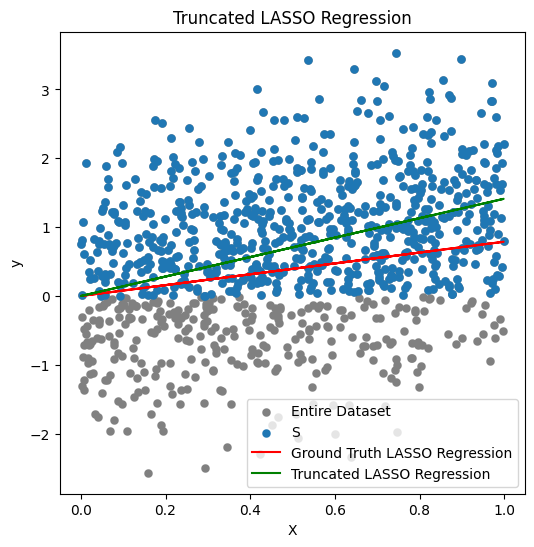

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lasso_reg.predict(X.sort()[0]), color='red', label='Ground Truth LASSO Regression')
ax.plot(X.sort()[0], trunc_lasso_reg.predict(X.sort()[0]), color='green', label='Truncated LASSO Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated LASSO Regression')
ax.legend()
plt.show()

In [7]:
import time

def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()

        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

In [8]:
num_samples = 1000

def phi(X): 
    return X > 0

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, num_samples, ch.ones(1, 1), 1, verbose=True)

alpha: 0.699


In [10]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLassoRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)
L1 = .1

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 2

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1)

        gt = LassoCV(alphas=[L1], fit_intercept=False)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten()]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LassoCV(alphas=[L1], fit_intercept=False)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten()]))

        emp_mse_loss = mse_loss(emp_, gt_).item()

        args = Parameters({
                            'trials': 1,
                            'batch_size': 10,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
#                             'verbose': True,
        })
        delphi_reg = TruncatedLassoRegression(args,
                                                phi,
                                                alpha, 
                                                l1=L1,
                                                noise_var=ch.Tensor([1.0]),
                                                fit_intercept=False)
        delphi_reg.fit(x_trunc, y_trunc)

        delphi_coef_ = delphi_reg.best_coef_
        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()

        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'delphi_mse': delphi_mse, 
        }

        results.append(result)
            
    
df = pd.DataFrame(results)

trial: 1, num samples: 100


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


trial: 1, num samples: 500


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


trial: 1, num samples: 1000


...

trial: 1, num samples: 3000


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


trial: 1, num samples: 4000


/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/patroklos/base/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


KeyboardInterrupt: 

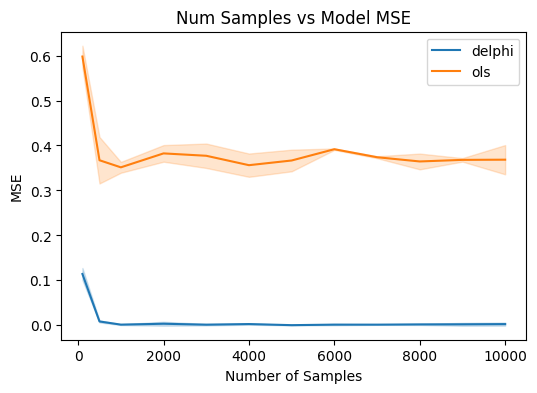

In [12]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax, label="ols")
ax.set_title('Num Samples vs Model MSE')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('MSE')

plt.show()

# 10 Dimension Truncated Regression - Varying Samples

In [13]:
def phi(x): 
    return x > 5

W = ch.ones(10, 1)
W0 = ch.ones(1, 1)
NUM_SAMPLES = 1000
x_trunc, y_trunc, alpha, X, Y = generate_data(phi, NUM_SAMPLES, W, W0, D=10, verbose=True)

alpha: 0.503


In [14]:
gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)
print(f'gt lin reg:\n {gt_lin_reg.coef_}')

trunc_lin_reg = LinearRegression(fit_intercept=True)
trunc_lin_reg.fit(x_trunc, y_trunc)
print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

gt lin reg:
 [[1.0509894 1.0000943 0.9940939 0.9819313 0.9861834 1.0868474 0.9699459
  1.0652944 1.050484  0.9736538]]
trunc lin reg W:
 [[0.56497973 0.4929279  0.47746435 0.7162838  0.5309008  0.5375781
  0.40332726 0.49947277 0.60698247 0.52413857]]


In [17]:
RAND_MATRIX = ch.randn(10, 2)

transformed_weights = ch.from_numpy(gt_lin_reg.coef_)@RAND_MATRIX
print(f'transformed weights: {transformed_weights}')

trunc_transformed_weights = ch.from_numpy(trunc_lin_reg.coef_)@RAND_MATRIX
print(f'trunc transformed weights: {trunc_transformed_weights}')

transformed_x = X@RAND_MATRIX
print(f'num samples: {transformed_x.size(0)}')
transformed_x_trunc = x_trunc@RAND_MATRIX
print(f'num truncated samples: {transformed_x_trunc.size(0)}')

transformed weights: tensor([[ 0.4375, -2.1919]])
trunc transformed weights: tensor([[ 0.1808, -0.9405]])
num samples: 3000
num truncated samples: 1000


/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


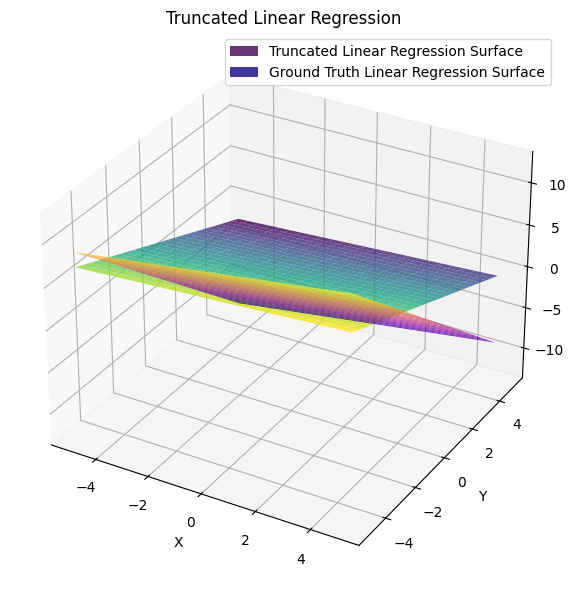

In [18]:
x_linspace = ch.linspace(-5, 5, 25)
y_linspace = ch.linspace(-5, 5, 25)
x_meshgrid, y_meshgrid = ch.meshgrid(x_linspace, y_linspace)

trunc_z = ch.zeros_like(x_meshgrid)
z = ch.zeros_like(x_meshgrid)
for i in range(len(x_linspace)): 
    for j in range(len(y_linspace)): 
        trunc_z[i, j] = trunc_transformed_weights@ch.cat([x_meshgrid[i, j][None,...], y_meshgrid[i, j][None,...]]) + ch.from_numpy(trunc_lin_reg.intercept_)
        z[i, j] = transformed_weights@ch.cat([x_meshgrid[i, j][None,...], y_meshgrid[i, j][None,...]]) + ch.from_numpy(gt_lin_reg.intercept_)

fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_subplot(111, projection='3d')
surf = ax1.plot_surface(x_meshgrid, y_meshgrid, trunc_z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Truncated Linear Regression Surface")
surf = ax1.plot_surface(x_meshgrid, y_meshgrid, z, cmap='plasma', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Ground Truth Linear Regression Surface")
# ax1.scatter(transformed_x[:,0][:100], transformed_x[:,1][:100], Y[:100], label="Entire Dataset")
# ax1.scatter(transformed_x_trunc[:,0][:100], transformed_x_trunc[:,1][:100], y_trunc[:100], label="Truncated Dataset")

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('PREDICTION')
ax1.set_title('Truncated Linear Regression')
ax1.legend()

plt.tight_layout()
plt.show()

In [19]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 5

W = ch.ones(10, 1)

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1, W0=ch.ones(1,1), D=10, verbose=True)

        gt = LinearRegression(fit_intercept=True)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))

        emp_mse_loss = mse_loss(emp_, gt_).item()

        args = Parameters({
                            'trials': 1,
                            'batch_size': 1,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
                            'step_lr_gamma': 1.0,
#                             'verbose': True,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                noise_var=ch.Tensor([1.0]),
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc, y_trunc)

        delphi_ = ch.concatenate([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_])

        delphi_mse = mse_loss(gt_, delphi_.flatten()).item()


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'delphi_mse': delphi_mse, 
        }

        results.append(result)
            
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
alpha: 0.555
ERROR! Session/line number was not unique in database. History logging moved to new session 74
trial: 1, num samples: 500
alpha: 0.487
trial: 1, num samples: 1000
alpha: 0.506
trial: 1, num samples: 2000
alpha: 0.499
trial: 1, num samples: 3000
alpha: 0.497
trial: 1, num samples: 4000
alpha: 0.513
trial: 1, num samples: 5000
alpha: 0.496
trial: 1, num samples: 6000
alpha: 0.499
trial: 1, num samples: 7000
alpha: 0.501
trial: 1, num samples: 8000
alpha: 0.501
trial: 1, num samples: 9000
alpha: 0.498
trial: 1, num samples: 10000
alpha: 0.499
trial: 2, num samples: 100
alpha: 0.423
trial: 2, num samples: 500
alpha: 0.511
trial: 2, num samples: 1000
alpha: 0.509
trial: 2, num samples: 2000
alpha: 0.492
trial: 2, num samples: 3000
alpha: 0.501
trial: 2, num samples: 4000
alpha: 0.506
trial: 2, num samples: 5000
alpha: 0.504
trial: 2, num samples: 6000
alpha: 0.490
trial: 2, num samples: 7000
alpha: 0.509
trial: 2, num samples: 8000
alpha: 0.500
trial:

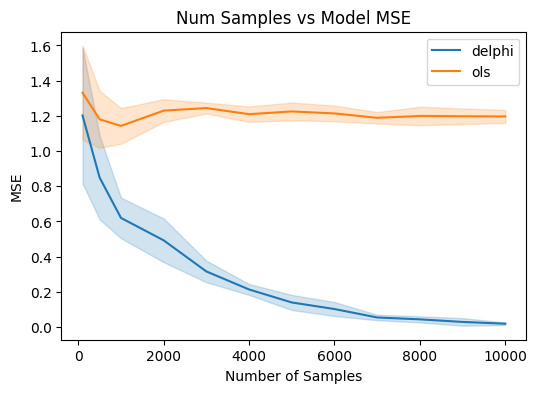

In [20]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax, label="ols")
ax.set_title('Num Samples vs Model MSE')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('MSE')

plt.show()

# 50 Dimensions Truncated Linear Regression - Varying Samples

In [36]:
D, num_samples = 50, 20000

def phi(X):
    return X > 25

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, num_samples, ch.ones(D, 1), 5.0, W0=ch.ones(1, 1), D=D, verbose=True)

alpha: 0.626


In [46]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X):
    return X > 25

W = ch.ones(D, 1)
NOISE_VAR = 3.0

NUM_SAMPLES = [1000*i for i in range(1, 21, 2)]
NUM_TRIALS = 10

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, NOISE_VAR, W0=ch.ones(1, 1), D=D, verbose=True)

        gt = LinearRegression(fit_intercept=True)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))

        emp_mse_loss = mse_loss(emp_, gt_).item()
        
        y_trunc_scale = (y_trunc) / (NOISE_VAR ** .5) 
        
        def phi_scale(x): 
            return x > (25 / (NOISE_VAR ** .5))

        args = Parameters({
                            'trials': 1,
                            'batch_size': 1,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
                            'step_lr_gamma': 1.0,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi_scale,
                                                alpha, 
                                                noise_var=ch.Tensor([1.0]),
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc, y_trunc_scale)

        delphi_ = ch.concatenate([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_]) * (NOISE_VAR ** .5)

        delphi_mse = mse_loss(gt_, delphi_.flatten()).item()


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'delphi_mse': delphi_mse, 
        }

        results.append(result)
            
    
df = pd.DataFrame(results)

trial: 1, num samples: 1000
alpha: 0.649
trial: 1, num samples: 3000
alpha: 0.642
trial: 1, num samples: 5000
alpha: 0.651
trial: 1, num samples: 7000
alpha: 0.644
trial: 1, num samples: 9000
alpha: 0.647
trial: 1, num samples: 11000
alpha: 0.645
trial: 1, num samples: 13000
alpha: 0.649
trial: 1, num samples: 15000
alpha: 0.646
trial: 1, num samples: 17000
alpha: 0.649
trial: 1, num samples: 19000
alpha: 0.641
trial: 2, num samples: 1000
alpha: 0.628
trial: 2, num samples: 3000
alpha: 0.642
trial: 2, num samples: 5000
alpha: 0.645
trial: 2, num samples: 7000
alpha: 0.651
trial: 2, num samples: 9000
alpha: 0.653
trial: 2, num samples: 11000
alpha: 0.643
trial: 2, num samples: 13000
alpha: 0.647
trial: 2, num samples: 15000
alpha: 0.647
trial: 2, num samples: 17000
alpha: 0.649
trial: 2, num samples: 19000
alpha: 0.649
trial: 3, num samples: 1000
alpha: 0.651
trial: 3, num samples: 3000
alpha: 0.637
trial: 3, num samples: 5000
alpha: 0.644
trial: 3, num samples: 7000
alpha: 0.640
trial:

KeyboardInterrupt: 

In [47]:
df = pd.DataFrame(results)

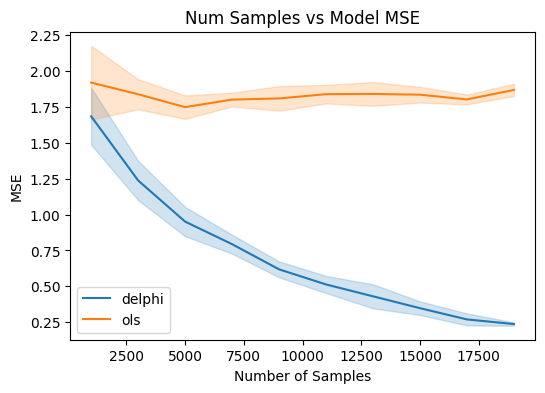

In [48]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax, label="ols")
ax.set_title('Num Samples vs Model MSE')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('MSE')

plt.show()

In [40]:
delphi_reg.trainer.param_history

tensor([[ 2.8504,  2.5304,  2.6356,  ...,  2.5955,  2.8581, -0.0854],
        [ 2.8403,  2.5230,  2.6223,  ...,  2.5802,  2.8523, -0.1943],
        [ 2.8473,  2.5296,  2.6287,  ...,  2.5850,  2.8574, -0.1017],
        ...,
        [ 3.9796,  3.0718,  3.5294,  ...,  2.9431,  3.9154, -3.3723],
        [ 3.9778,  3.0708,  3.5285,  ...,  2.9398,  3.9147, -3.3961],
        [ 3.9821,  3.0756,  3.5300,  ...,  2.9416,  3.9175, -3.3616]])

In [42]:
delphi_reg.trainer.param_history[-1][:-1] * (3.0 ** .5)

tensor([6.8972, 5.3271, 6.1142, 6.4315, 6.0846, 5.4556, 6.0012, 6.7757, 6.3397,
        6.5248, 7.2276, 5.9761, 6.6080, 5.9729, 5.4221, 5.7798, 6.4922, 5.5772,
        5.8480, 6.5310, 5.7776, 5.9867, 5.7968, 5.8291, 5.8829, 7.2368, 6.3318,
        5.2345, 6.2477, 6.2591, 6.0289, 6.3338, 6.8683, 7.2167, 6.5444, 5.6678,
        6.5290, 6.5837, 6.2259, 5.9870, 7.2064, 5.6423, 5.9236, 6.3329, 5.9709,
        6.1151, 6.9379, 6.1684, 5.0950, 6.7853])